In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

ml_df = pd.read_csv("Dataset/ML_Train_Level_Data.csv")

ml_df.head()

,Train_No,Journey_Duration_Minutes,Total_Distance,Number_of_Stops
0,107,105.0,78,4
1,108,115.0,83,4
2,128,1325.0,978,22
3,290,9120.0,2694,14
4,401,2190.0,1618,12


In [9]:
X = ml_df[["Total_Distance", "Number_of_Stops"]]
y = ml_df["Journey_Duration_Minutes"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

final_model = LinearRegression()

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

In [10]:
distance = float(input("Enter Total Distance (km): "))
stops = int(input("Enter Number of Stops: "))

In [11]:
user_data = pd.DataFrame({
    "Total_Distance": [distance],
    "Number_of_Stops": [stops]
})

predicted_minutes = final_model.predict(user_data)[0]

print("Predicted Journey Duration:", round(predicted_minutes, 2), "minutes")

Predicted Journey Duration: 1188.8 minutes


In [12]:
hours = int(predicted_minutes // 60)
minutes = int(predicted_minutes % 60)

print("Predicted Journey Duration:")
print(hours, "hours", minutes, "minutes")

Predicted Journey Duration:
19 hours 48 minutes


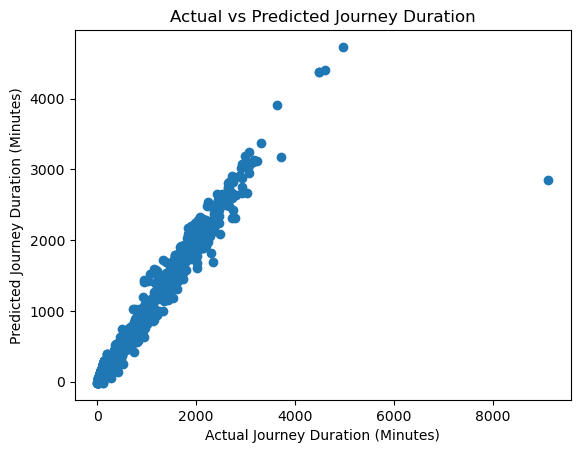

In [13]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Journey Duration (Minutes)")
plt.ylabel("Predicted Journey Duration (Minutes)")
plt.title("Actual vs Predicted Journey Duration")

plt.show()

In [14]:
def predict_journey(distance, stops):
    user_data = pd.DataFrame({
        "Total_Distance": [distance],
        "Number_of_Stops": [stops]
    })

    prediction = final_model.predict(user_data)[0]

    hours = int(prediction // 60)
    minutes = int(prediction % 60)

    print("Predicted Duration:", round(prediction, 2), "minutes")
    print("Approximate Time:", hours, "hours", minutes, "minutes")

In [15]:
predict_journey(1000, 20)

Predicted Duration: 1127.23 minutes
Approximate Time: 18 hours 47 minutes


In [16]:
predict_journey(500, 10)

Predicted Duration: 548.16 minutes
Approximate Time: 9 hours 8 minutes


In [17]:
predict_journey(1000, 20)

Predicted Duration: 1127.23 minutes
Approximate Time: 18 hours 47 minutes
